## Random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/Heart.csv", index_col=0)

df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


<Axes: xlabel='AHD', ylabel='count'>

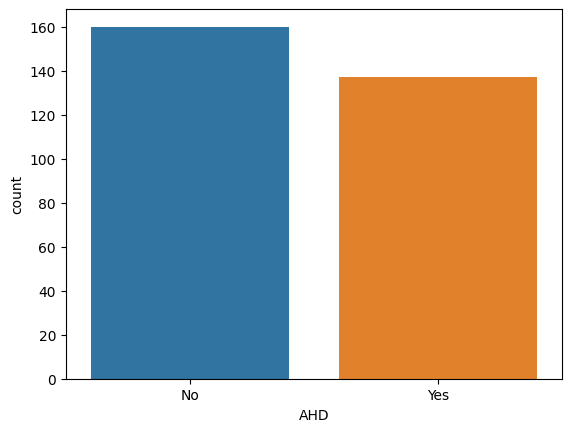

In [22]:
df.dropna(inplace=True)

sns.countplot(data=df, x= "AHD", hue="AHD" )

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


## Random forest classifier

In [24]:
df_dummies = pd.get_dummies(df, drop_first=True)

df_dummies.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False,False


In [25]:
from sklearn.model_selection import train_test_split

X, y = df_dummies.drop("AHD_Yes", axis=1), df_dummies["AHD_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
    
)

X_train.shape, X_test.shape

((198, 16), (99, 16))

In [26]:
X_train.head(
)

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
32,60,1,117,230,1,0,160,1,1.4,1,2.0,False,False,False,False,True
173,59,0,174,249,0,0,143,1,0.0,2,0.0,False,False,False,True,False
149,45,1,128,308,0,2,170,0,0.0,1,0.0,False,True,False,True,False
225,63,0,108,269,0,0,169,1,1.8,2,2.0,False,False,False,True,False
116,41,1,135,203,0,0,132,0,0.0,2,0.0,False,True,False,False,False


In [27]:
y_train.head()

32      True
173     True
149    False
225     True
116    False
Name: AHD_Yes, dtype: bool

In [30]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
y_pred

array([False,  True, False,  True, False, False,  True,  True,  True,
       False, False, False, False,  True,  True, False, False, False,
        True, False,  True,  True,  True, False,  True, False,  True,
        True, False, False, False, False,  True, False, False, False,
        True, False,  True,  True, False,  True,  True,  True, False,
        True,  True,  True, False, False, False,  True, False, False,
        True, False, False, False,  True,  True, False, False,  True,
       False, False, False,  True, False,  True,  True,  True,  True,
        True, False,  True, False, False, False, False, False, False,
        True,  True,  True,  True, False, False,  True, False,  True,
        True,  True, False, False, False,  True, False, False, False])

## Evaluation

              precision    recall  f1-score   support

       False       0.81      0.83      0.82        53
        True       0.80      0.78      0.79        46

    accuracy                           0.81        99
   macro avg       0.81      0.81      0.81        99
weighted avg       0.81      0.81      0.81        99



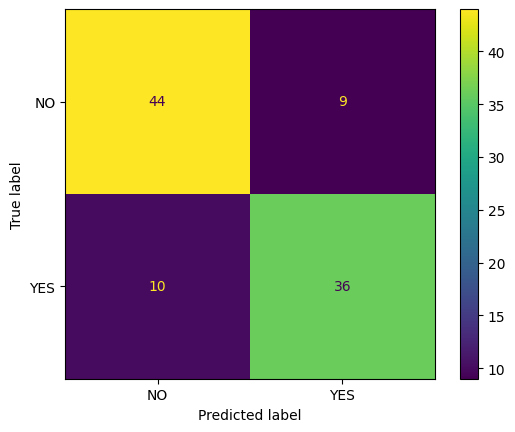

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["NO", "YES"]).plot()


In [ ]:
model_rf.feature_importances_

array([0.0931407 , 0.03372479, 0.07013429, 0.0792663 , 0.00730311,
       0.02068672, 0.1240207 , 0.04023465, 0.10045081, 0.02231842,
       0.17844666, 0.04327672, 0.00937807, 0.01567818, 0.09106361,
       0.07087628])

In [ ]:
model_rf.feature_importances_.shape, X_train.shape

((16,), (198, 16))

In [ ]:
model_rf.feature_importances_.sum()

np.float64(1.0)

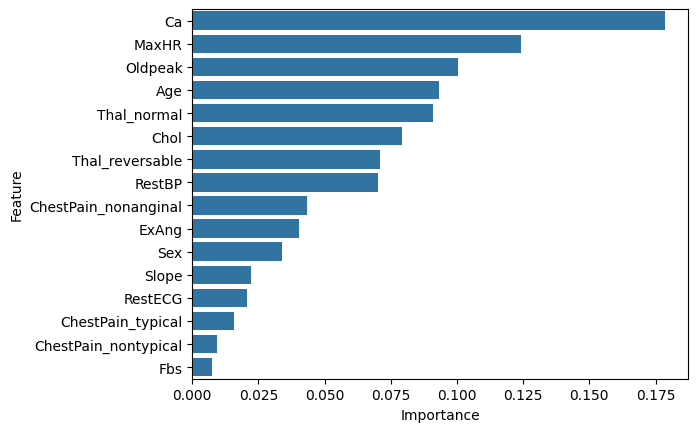

In [ ]:
feature_importance = pd.DataFrame([X.columns, model_rf.feature_importances_]).T
feature_importance.columns = ["Feature", "Importance"]
feature_importance.sort_values(by = "Importance", ascending = False, inplace = True)
sns.barplot(data = feature_importance, x = "Importance", y = "Feature");